In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\77017\Desktop\ecommerce_customer_behavior_dataset_v2.csv")
print(df.head(5))

       Order_ID Customer_ID        Date  Age Gender      City  \
0  ORD_000001-1  CUST_00001  2023-05-29   40   Male    Ankara   
1  ORD_000001-2  CUST_00001  2023-10-12   40   Male    Ankara   
2  ORD_000001-3  CUST_00001  2023-12-05   40   Male    Ankara   
3  ORD_000002-1  CUST_00002  2023-05-11   33   Male  Istanbul   
4  ORD_000002-2  CUST_00002  2023-06-16   33   Male  Istanbul   

  Product_Category  Unit_Price  Quantity  Discount_Amount  Total_Amount  \
0            Books       29.18         1             0.00         29.18   
1    Home & Garden      644.40         1           138.05        506.35   
2           Sports      332.82         5             0.00       1664.10   
3             Food       69.30         5            71.05        275.45   
4           Beauty      178.15         3             0.00        534.45   

   Payment_Method Device_Type  Session_Duration_Minutes  Pages_Viewed  \
0  Digital Wallet      Mobile                        14             9   
1     Credit

In [23]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df.describe())

(17049, 18)
Order_ID                        str
Customer_ID                     str
Date                            str
Age                           int64
Gender                          str
City                            str
Product_Category                str
Unit_Price                  float64
Quantity                      int64
Discount_Amount             float64
Total_Amount                float64
Payment_Method                  str
Device_Type                     str
Session_Duration_Minutes      int64
Pages_Viewed                  int64
Is_Returning_Customer          bool
Delivery_Time_Days            int64
Customer_Rating               int64
dtype: object
Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount              

In [24]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
print(df[['Date','Month', 'Year']].head())

        Date  Month  Year
0 2023-05-29      5  2023
1 2023-10-12     10  2023
2 2023-12-05     12  2023
3 2023-05-11      5  2023
4 2023-06-16      6  2023


    Year  Month  Total_Amount   Period
0   2023      1    1311603.21   2023-1
1   2023      2    1409777.29   2023-2
2   2023      3    1458005.58   2023-3
3   2023      4    1499648.03   2023-4
4   2023      5    1483511.61   2023-5
5   2023      6    1380984.94   2023-6
6   2023      7    1560046.14   2023-7
7   2023      8    1510999.75   2023-8
8   2023      9    1502164.37   2023-9
9   2023     10    1536847.33  2023-10
10  2023     11    1446439.79  2023-11
11  2023     12    1586213.77  2023-12
12  2024      1    1490824.78   2024-1
13  2024      2    1329884.01   2024-2
14  2024      3    1272101.99   2024-3


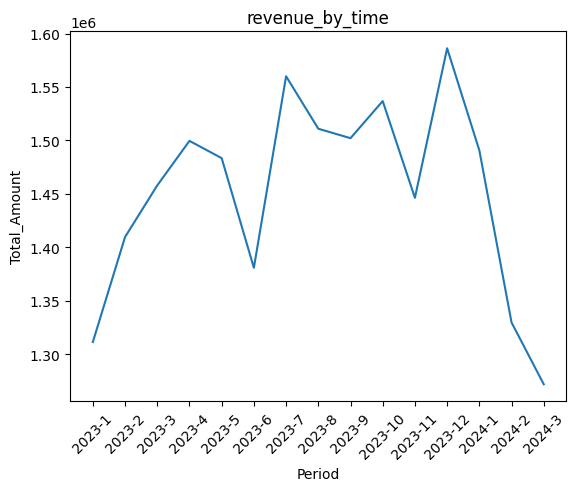

In [25]:
revenue_by_time = df.groupby(['Year', 'Month'])['Total_Amount'].sum().reset_index()
revenue_by_time['Period'] = revenue_by_time['Year'].astype(str) + '-' + revenue_by_time['Month'].astype(str)


plt.plot(revenue_by_time['Period'], revenue_by_time['Total_Amount'])
plt.title('revenue_by_time')
plt.xlabel('Period')
plt.ylabel('Total_Amount')
plt.xticks(rotation=45)


print(revenue_by_time)
plt.show()

In [26]:
df['Age Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 100], labels=['18-25', '26-35', '36-45', '46-55', '55+'])
clients_by_age = df.groupby('Age Group')['Customer_ID'].size().reset_index()
clients_by_age = clients_by_age.rename(columns = {'Customer_ID' : 'Number of Clients'})
print(clients_by_age)

  Age Group  Number of Clients
0     18-25               2236
1     26-35               5183
2     36-45               4997
3     46-55               2402
4       55+                626


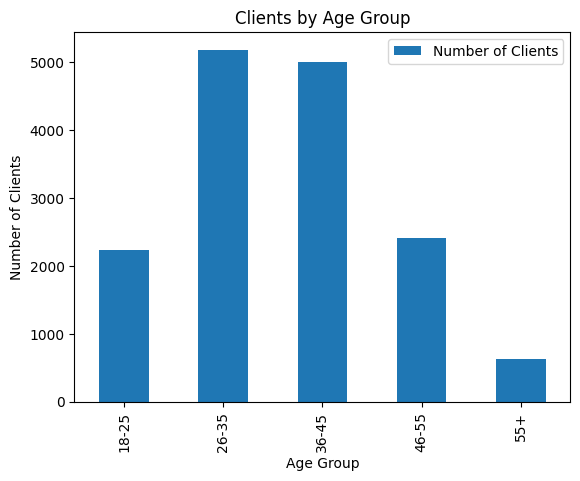

In [27]:
clients_by_age.plot(kind = 'bar', x = 'Age Group', y = 'Number of Clients') 
plt.title('Clients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Clients')
plt.show()

In [28]:
gender = df.groupby('Gender').agg(Orders = ('Order_ID', 'count'), Average_Check = ('Total_Amount', 'mean'), Average_Rating = ('Customer_Rating', 'mean')).reset_index()
print(gender)

   Gender  Orders  Average_Check  Average_Rating
0  Female    8613    1281.549356        3.904331
1    Male    8176    1265.066744        3.896282
2   Other     260    1530.316500        3.834615


In [29]:
payment_methods = df.groupby('Payment_Method').agg(
    Orders = ('Order_ID', 'count'), 
    Average_Check = ('Total_Amount', 'mean'), 
    Average_Rating = ('Customer_Rating', 'mean')
).reset_index().sort_values(by = 'Average_Check', ascending= False)

print(payment_methods)

     Payment_Method  Orders  Average_Check  Average_Rating
2       Credit Card    6801    1333.585451        3.899132
0     Bank Transfer    1763    1311.116988        3.897901
4    Digital Wallet    3276    1279.561050        3.872100
3        Debit Card    4321    1192.358905        3.917612
1  Cash on Delivery     888    1186.727320        3.916667


In [34]:
rating_correlation = df.corr(numeric_only=True)['Customer_Rating']
print(rating_correlation)

Age                        -0.003152
Unit_Price                 -0.002999
Quantity                   -0.003355
Discount_Amount             0.002004
Total_Amount                0.000879
Session_Duration_Minutes   -0.002156
Pages_Viewed               -0.012639
Is_Returning_Customer       0.007059
Delivery_Time_Days         -0.008480
Customer_Rating             1.000000
Month                       0.000222
Year                        0.007129
Name: Customer_Rating, dtype: float64


In [31]:
average_rating = df.groupby('Product_Category')['Customer_Rating'].mean().reset_index()
print(average_rating)

  Product_Category  Customer_Rating
0           Beauty         3.921338
1            Books         3.881233
2      Electronics         3.898264
3          Fashion         3.887160
4             Food         3.862577
5    Home & Garden         3.930097
6           Sports         3.918149
7             Toys         3.895215


<Axes: >

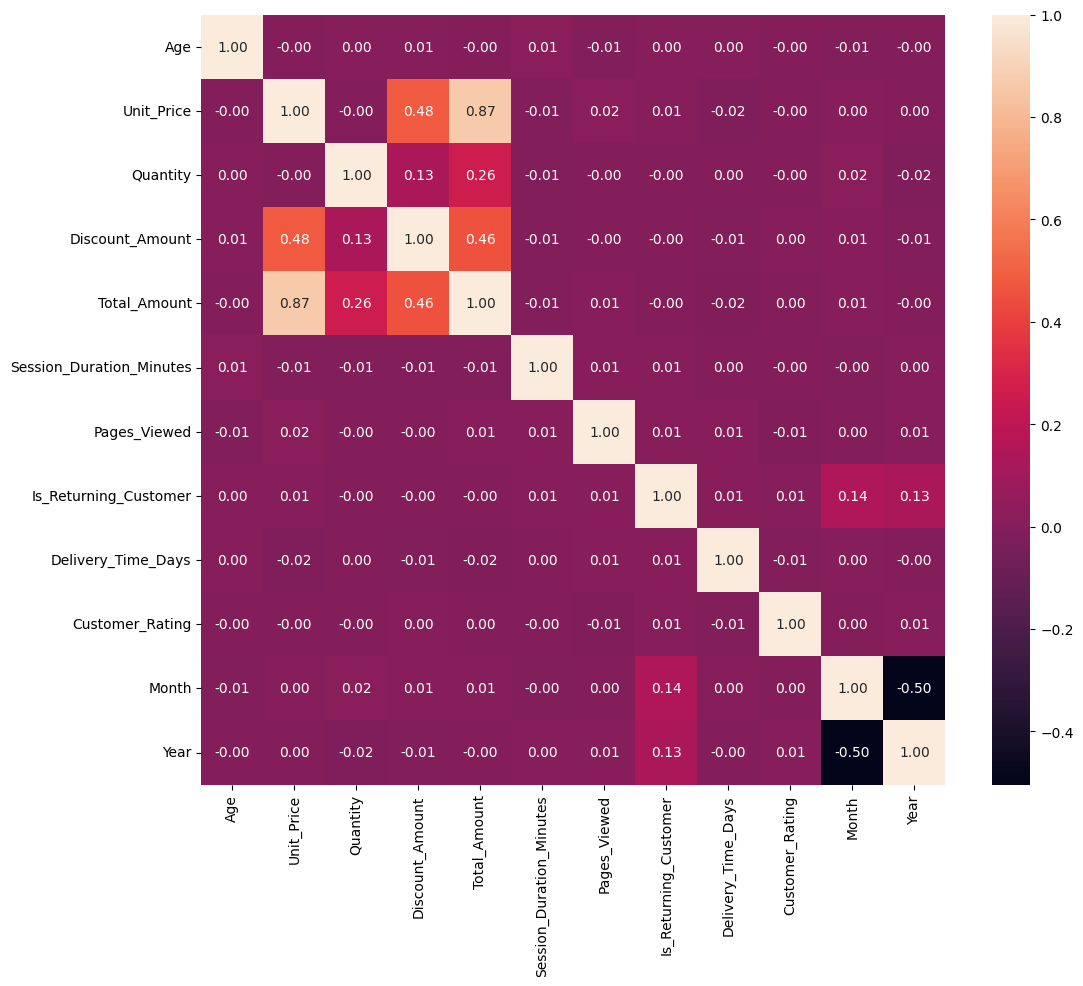

In [41]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only= True), annot= True, fmt='.2f')